In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results = pd.read_csv('results.csv')
results

,mapping,ordering,w,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
0,001,0_001,11,0.930739,0.513033,0.971580,0.967814,0.893595,0.972426,0.967727,0.890358,0.965845,0.967118,0.893205,0.897244,0.887621,0.893964
1,001,0_001,5,0.773958,1.421525,0.960938,0.850781,0.660937,0.960938,0.849219,0.660937,0.850781,0.849219,0.660937,0.660937,0.660937,0.660937
2,001,0_001,8,0.882212,0.796449,0.974770,0.949992,0.818804,0.975250,0.943954,0.804980,0.946801,0.944542,0.815558,0.808486,0.800160,0.804198
3,001,0_010,11,0.747321,1.962490,0.681273,0.838027,0.836070,0.675881,0.665305,0.654438,0.836689,0.660586,0.806200,0.838727,0.663948,0.809676
4,001,0_010,5,0.628646,1.934916,0.540625,0.640625,0.669531,0.540625,0.682813,0.571094,0.640625,0.682813,0.667188,0.669531,0.571094,0.667188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16816,codon,9,5,0.387370,3.790936,0.407813,0.416406,0.316406,0.407813,0.397656,0.428125,0.416406,0.397656,0.357812,0.316406,0.428125,0.357812
16817,codon,9,8,0.559917,3.288811,0.548671,0.538277,0.472417,0.537538,0.613569,0.616080,0.542284,0.619839,0.571436,0.472838,0.617784,0.568417
16818,codon,k3_alphabetical,11,0.710973,2.807030,0.535372,0.578236,0.538040,0.544427,0.829124,0.888651,0.584545,0.832687,0.881858,0.543101,0.891794,0.880683
16819,codon,k3_alphabetical,5,0.456771,3.661167,0.355469,0.379687,0.322656,0.355469,0.482031,0.589063,0.379687,0.482031,0.611719,0.322656,0.589063,0.611719


In [3]:
optimized_orders = results[(results['ordering'] != 'k3_alphabetical') & (results['ordering'].str.contains('_')) & (results['ordering'].str.split('_').str[1] == results['mapping'])]
optimized_orders

,mapping,ordering,w,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
0,001,0_001,11,0.930739,0.513033,0.971580,0.967814,0.893595,0.972426,0.967727,0.890358,0.965845,0.967118,0.893205,0.897244,0.887621,0.893964
1,001,0_001,5,0.773958,1.421525,0.960938,0.850781,0.660937,0.960938,0.849219,0.660937,0.850781,0.849219,0.660937,0.660937,0.660937,0.660937
2,001,0_001,8,0.882212,0.796449,0.974770,0.949992,0.818804,0.975250,0.943954,0.804980,0.946801,0.944542,0.815558,0.808486,0.800160,0.804198
24,001,10_001,11,0.952758,0.427627,0.991755,0.995439,0.908315,0.991682,0.991537,0.913809,0.995357,0.992238,0.915560,0.912219,0.912147,0.912947
25,001,10_001,5,0.771354,1.453591,0.849219,0.948438,0.661719,0.849219,0.847656,0.660937,0.948438,0.847656,0.660156,0.661719,0.660937,0.660156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16789,codon,99_codon,5,0.500911,3.290999,0.392188,0.637500,0.589063,0.392188,0.392188,0.417188,0.637500,0.392188,0.577344,0.589063,0.417188,0.577344
16790,codon,99_codon,8,0.664633,2.590449,0.529191,0.789827,0.816287,0.531156,0.529156,0.538808,0.784669,0.523594,0.790543,0.812967,0.536450,0.793026
16812,codon,9_codon,11,0.789927,1.622212,0.756684,0.828707,0.799635,0.758987,0.759494,0.769331,0.829619,0.759091,0.825513,0.798917,0.771650,0.822210
16813,codon,9_codon,5,0.527083,3.055529,0.510938,0.510938,0.575000,0.510938,0.470313,0.576562,0.510938,0.470313,0.518750,0.575000,0.576562,0.518750


In [4]:
optimized_orders.groupby(['mapping', 'w'])['global_masking_rate'].quantile([0.1, 0.5, 0.9]).unstack(level=-1).round(4) * 100

0.1    0.5    0.9
mapping w                      
001     5   75.31  77.33  77.50
        8   84.11  87.84  89.11
        11  89.40  93.10  94.97
010     5   75.69  77.50  77.50
        8   86.29  89.57  90.13
        11  92.07  94.87  95.66
011     5   54.06  55.58  56.39
        8   67.15  68.94  70.15
        11  74.33  76.24  77.85
100     5   75.13  77.40  77.50
        8   83.85  87.95  89.21
        11  89.45  93.40  94.84
101     5   50.99  52.14  52.59
        8   66.32  67.74  68.50
        11  74.19  75.76  76.95
110     5   54.15  55.90  56.34
        8   67.27  69.05  70.22
        11  74.71  76.51  77.89
codon   5   51.24  53.14  54.42
        8   66.42  68.77  70.23
        11  74.15  76.84  78.97

In [5]:
optimized_orders.groupby(['mapping', 'w'])['entropy'].quantile([0.1, 0.5, 0.9]).unstack(level=-1).round(2)

0.1   0.5   0.9
mapping w                   
001     5   1.42  1.42  1.48
        8   0.80  0.84  1.04
        11  0.44  0.53  0.78
010     5   1.42  1.42  1.48
        8   0.75  0.78  0.93
        11  0.40  0.44  0.64
011     5   3.07  3.11  3.17
        8   2.31  2.40  2.51
        11  1.94  2.01  2.16
100     5   1.42  1.42  1.49
        8   0.79  0.84  1.06
        11  0.44  0.51  0.79
101     5   3.25  3.28  3.34
        8   2.46  2.52  2.65
        11  2.02  2.09  2.26
110     5   3.07  3.10  3.19
        8   2.30  2.39  2.52
        11  1.91  2.01  2.17
codon   5   3.01  3.16  3.27
        8   2.12  2.41  2.57
        11  1.66  2.00  2.22

In [6]:
optimized_orders

,mapping,ordering,w,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
0,001,0_001,11,0.930739,0.513033,0.971580,0.967814,0.893595,0.972426,0.967727,0.890358,0.965845,0.967118,0.893205,0.897244,0.887621,0.893964
1,001,0_001,5,0.773958,1.421525,0.960938,0.850781,0.660937,0.960938,0.849219,0.660937,0.850781,0.849219,0.660937,0.660937,0.660937,0.660937
2,001,0_001,8,0.882212,0.796449,0.974770,0.949992,0.818804,0.975250,0.943954,0.804980,0.946801,0.944542,0.815558,0.808486,0.800160,0.804198
24,001,10_001,11,0.952758,0.427627,0.991755,0.995439,0.908315,0.991682,0.991537,0.913809,0.995357,0.992238,0.915560,0.912219,0.912147,0.912947
25,001,10_001,5,0.771354,1.453591,0.849219,0.948438,0.661719,0.849219,0.847656,0.660937,0.948438,0.847656,0.660156,0.661719,0.660937,0.660156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16789,codon,99_codon,5,0.500911,3.290999,0.392188,0.637500,0.589063,0.392188,0.392188,0.417188,0.637500,0.392188,0.577344,0.589063,0.417188,0.577344
16790,codon,99_codon,8,0.664633,2.590449,0.529191,0.789827,0.816287,0.531156,0.529156,0.538808,0.784669,0.523594,0.790543,0.812967,0.536450,0.793026
16812,codon,9_codon,11,0.789927,1.622212,0.756684,0.828707,0.799635,0.758987,0.759494,0.769331,0.829619,0.759091,0.825513,0.798917,0.771650,0.822210
16813,codon,9_codon,5,0.527083,3.055529,0.510938,0.510938,0.575000,0.510938,0.470313,0.576562,0.510938,0.470313,0.518750,0.575000,0.576562,0.518750


In [7]:
plot_data = optimized_orders[optimized_orders['mapping'].isin(['codon', '110', '100'])]

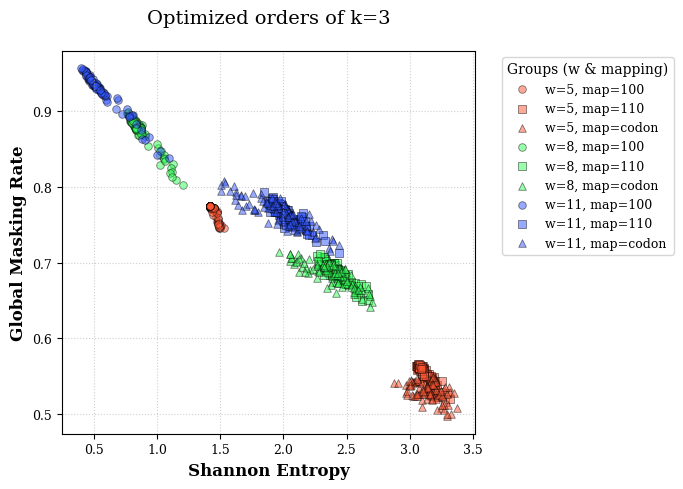

In [11]:
import matplotlib.colors as mcolors

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# 1. Setup categorical mappings
unique_w = sorted(plot_data['w'].unique())
unique_maps = plot_data['mapping'].unique()

# Define distinct colors for the 3 'w' options
colors = ['#FF5733', '#33FF57', '#3357FF'] # Or use plt.cm.Set1
w_color_map = {val: colors[i] for i, val in enumerate(unique_w)}

# Define markers for the mappings
available_markers = ['o', 's', '^', 'D', 'v']
marker_map = {m: available_markers[i % len(available_markers)] for i, m in enumerate(unique_maps)}

fig, ax = plt.subplots(figsize=(7, 5))

for w_val in unique_w:
    for map_val in unique_maps:
        subset = plot_data[
            (plot_data['w'] == w_val) & 
            (plot_data['mapping'] == map_val)
        ]
        
        if not subset.empty:
            ax.scatter(
                subset['entropy'], 
                subset['global_masking_rate'], 
                color=w_color_map[w_val], 
                marker=marker_map[map_val],
                s=30, 
                alpha=0.5,
                edgecolors='black',
                linewidth=0.6,
                # This label helps create a clean combined legend
                label=f"w={w_val}, map={map_val}"
            )

# 3. Aesthetics
ax.set_xlabel('Shannon Entropy', fontsize=12, fontweight='semibold')
ax.set_ylabel('Global Masking Rate', fontsize=12, fontweight='semibold')
ax.set_title('Optimized orders of k=3', fontsize=14, pad=20)

ax.grid(True, linestyle=':', alpha=0.6)

# 4. Legend - Placed outside to keep the plot clean
ax.legend(title='Groups (w & mapping)', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('optimized_orders_scatter.png', dpi=300, bbox_inches='tight')
plt.savefig('optimized_orders_scatter.svg', dpi=300, bbox_inches='tight')
plt.savefig('optimized_orders_scatter.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
idx = optimized_orders[optimized_orders['mapping'] == '110'].groupby('w')['global_masking_rate'].idxmax()
max_per_w = optimized_orders.loc[idx]
max_per_w

,mapping,ordering,w,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
13975,110,83_110,5,0.566016,3.068541,0.544531,0.587500,0.511719,0.544531,0.591406,0.614844,0.587500,0.591406,0.546094,0.511719,0.614844,0.546094
14144,110,8_110,8,0.711050,2.291581,0.659733,0.702542,0.650085,0.658810,0.761597,0.752039,0.705415,0.767409,0.743376,0.649857,0.747207,0.734451
14142,110,8_110,11,0.793609,1.848019,0.746715,0.773553,0.730278,0.745808,0.873248,0.819940,0.773105,0.872435,0.824818,0.727088,0.814991,0.819664


In [40]:
optimized_orders[(optimized_orders['mapping'] == '110') & (optimized_orders['ordering'].str.startswith('8_'))]

,mapping,ordering,w,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
14142,110,8_110,11,0.793609,1.848019,0.746715,0.773553,0.730278,0.745808,0.873248,0.819940,0.773105,0.872435,0.824818,0.727088,0.814991,0.819664
14143,110,8_110,5,0.565885,3.070501,0.536719,0.561719,0.545312,0.536719,0.559375,0.625781,0.561719,0.559375,0.566406,0.545312,0.625781,0.566406
14144,110,8_110,8,0.711050,2.291581,0.659733,0.702542,0.650085,0.658810,0.761597,0.752039,0.705415,0.767409,0.743376,0.649857,0.747207,0.734451
